In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [34]:
import random

## Generates N random points for logistic regression on a third order polynomial with the equation y = x^3 + 2x^2 -5x -6 by default
def generate_lr(N=20,w0=-6,w1=-5,w2=2,w3=-6,w4=0):
    n = 0
    X1 = []
    Y = []
    while(n < N):
        x1 = random.uniform(-5,5)
        x2 = random.uniform(-2,2)
        y = w0 + w1*x1 + w2*(x1**2) + w3*(x1**3) + w4*(x1**4) + x2
        X1.append(x1)
        Y.append(y)
        n += 1
    data = [np.array([1,X1[i],Y[i]]) for i in range(N)]
    return data

In [35]:
f_w0, f_w1, f_w2, f_w3, f_w4 = 0, 1, 0, 0, 0
N = 10
data = generate_lr(N, f_w0, f_w1, f_w2, f_w3, f_w4)

In [36]:
def abline(slope, intercept, color='b'):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept), c=color )

In [37]:
def plot4poly(w0,w1,w2,w3,w4, color='red'):
  axes = plt.gca()
  xlims = axes.get_xlim()
  ylims = axes.get_ylim()
  x1 = np.linspace(xlims[0], xlims[1], 1000)
  x2 = np.linspace(ylims[0], ylims[1], 1000)
  # meshgrid
  XM1, XM2 = np.meshgrid(x1, x2)
  def f(x1, x2, w0, w1, w2, w3, w4):
    return w0 + w1*x1 + w2*(x1**2) + w3*(x1**3) + w4*(x1**4) - x2
  plt.contour(XM1, XM2, f(XM1, XM2, w0, w1, w2, w3, w4), 1, colors = color)

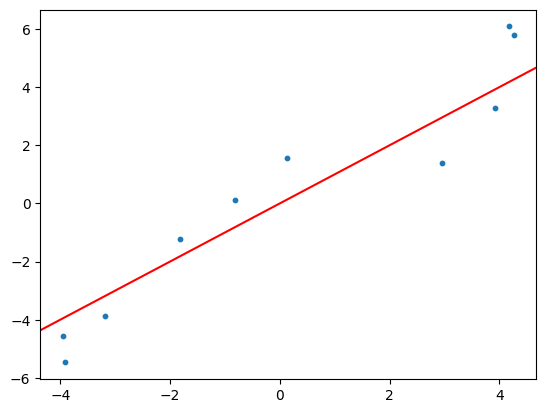

In [38]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
cnt = 0
plt.scatter(X1,Y, s = 10)

#abline(f_w1,f_w0)
plot4poly(f_w0,f_w1,f_w2,f_w3,f_w4)
plt.show()

In [39]:
#X = [[i[0], i[1], i[1]**2, i[1]**3, i[1]**4] for i in data]
X = [[i[0], i[1], i[1]**2, i[1]**3, i[1]**4] for i in data]
Y  = [i[2] for i in data]
dp=5

In [40]:
def lr(X, y):
  XtX = np.matmul(np.transpose(X), X)
  XtX_inv = np.linalg.inv(XtX)
  X_pi = np.matmul(XtX_inv, np.transpose(X))
  w = np.matmul(X_pi, Y)
  return w

In [41]:
w = lr(X, Y)
w

array([ 1.2220099 ,  0.44375186, -0.50612573,  0.04539647,  0.02577251])

Plot the final hypothesis with the target and the data points

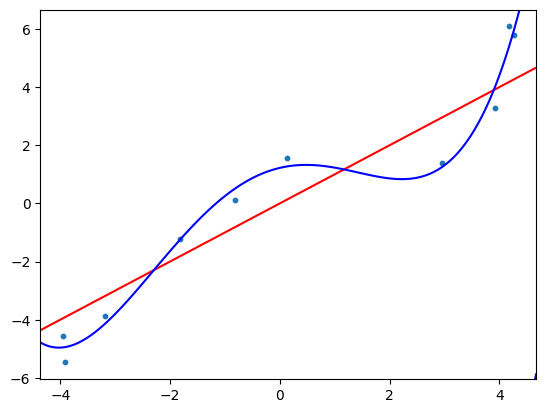

In [42]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
plt.scatter(X1,Y, s = 10)

plot4poly(f_w0,f_w1,f_w2,f_w3,f_w4)
plot4poly(w[0],w[1],w[2],w[3],w[4], color='blue')
#abline(w[1], w[0], color='blue')

plt.show()

In [43]:
#50 test samples
testdata = generate_lr(50, f_w0, f_w1, f_w2, f_w3, f_w4)
X_test = [[i[0], i[1], i[1]**2, i[1]**3, i[1]**4] for i in testdata]
Y_test  = [i[2] for i in testdata]
Y_pred_test = np.matmul(X_test, w)
np.sum(np.square(Y_pred_test-Y_test))

108.87268136466446

In [44]:
Y_pred_test_target = np.matmul(X_test, [f_w0, f_w1, f_w2, f_w3, f_w4])
np.sum(np.square(Y_pred_test_target-Y_test))

76.58622160043285

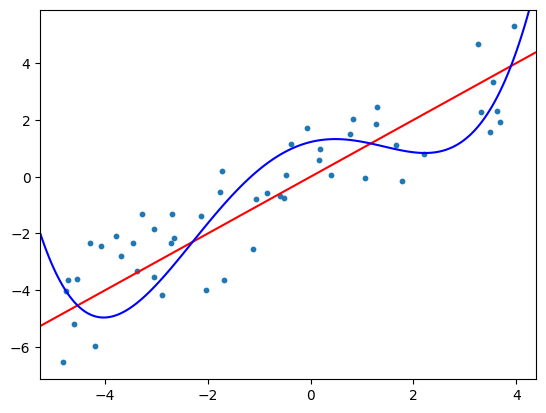

In [45]:
X1 = [i[1] for i in X_test]

plt.scatter(X1,Y_test, s = 10)

plot4poly(f_w0,f_w1,f_w2,f_w3,f_w4)
plot4poly(w[0],w[1],w[2],w[3],w[4], color='blue')

plt.show()